![imagen](https://cdn.foodbeast.com/content/wp-content/uploads/2012/03/beer-print-01-selectism.jpg)

# Ejercicio pandas estadística
Para este ejercicio se ha utilizado [un dataset de un concurso de kaggle](https://www.kaggle.com/nickhould/craft-cans), cuyo reto consiste en predecir el tipo de cerveza en función de sus características (nivel de alcohol, amargura, tamaño...).

# Ejercicio 1
Importa las librerias que consideres

In [127]:
import pandas as pd
import numpy as np

## Ejercicio 2
1. Importa el dataset "datasets_beer.csv"
2. Imprime por pantalla los primeros registros.
3. ¿Cuáles son sus columnas?
4. ¿Qué dimensiones tiene el DataFrame?

In [128]:
# Importar el dataset, lo más importante es copiar bien la ruta, y mirar cómo está delimitado:
beers = pd.read_csv('data/datasets_beers.csv')

In [129]:
# Imprimir por pantalla los primeros registros, no especifíca cuántos, pero pongo 10, que me parece mejor que 5:
beers.head(10)

,Unnamed: 0,abv,ibu,id,name,style,brewery_id,ounces
0,0,0.050,NaN,1436,Pub Beer,American Pale Lager,408,12.0
1,1,0.066,NaN,2265,Devil's Cup,American Pale Ale (APA),177,12.0
2,2,0.071,NaN,2264,Rise of the Phoenix,American IPA,177,12.0
3,3,0.090,NaN,2263,Sinister,American Double / Imperial IPA,177,12.0
4,4,0.075,NaN,2262,Sex and Candy,American IPA,177,12.0
5,5,0.077,NaN,2261,Black Exodus,Oatmeal Stout,177,12.0
6,6,0.045,NaN,2260,Lake Street Express,American Pale Ale (APA),177,12.0
7,7,0.065,NaN,2259,Foreman,American Porter,177,12.0
8,8,0.055,NaN,2258,Jade,American Pale Ale (APA),177,12.0
9,9,0.086,NaN,2131,Cone Crusher,American Double / Imperial IPA,177,12.0


In [130]:
# Para comprobar sus columnas pueden usarse varias formas, la más directa es .columns, pero me gusta más .info().
beers.columns
# El dataframe tiene 8 columnas diferentes.

Index(['Unnamed: 0', 'abv', 'ibu', 'id', 'name', 'style', 'brewery_id',
       'ounces'],
      dtype='str')

In [131]:
# Para ver las dimensiones de un dataframe también hay muchas formas, y como antes no la he usado y es la que más me gusta por la información que da la uso ahora:
beers.info()
# Aquí podemos ver que es un dataframe de pandas, que tiene 2410 entradas, el número de columnas (8), nombre de las columnas, cuántos valores nulos tiene cada una, 
# el tipo de dato que contienen y cuánta memoria está usando. Por lo tanto las dimensiones del dataframe es de 8 columnas y 2410 filas o entradas (2410x8)

<class 'pandas.DataFrame'>
RangeIndex: 2410 entries, 0 to 2409
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  2410 non-null   int64  
 1   abv         2348 non-null   float64
 2   ibu         1405 non-null   float64
 3   id          2410 non-null   int64  
 4   name        2410 non-null   str    
 5   style       2405 non-null   str    
 6   brewery_id  2410 non-null   int64  
 7   ounces      2410 non-null   float64
dtypes: float64(3), int64(3), str(2)
memory usage: 150.8 KB


In [132]:
# Pero lo más directo sería hacerlo con un beers.shape que te dice directamente las dimensiones, pero info() da más información.
beers.shape
# 2410 filas y 8 columnas

(2410, 8)

## Ejercicio 3
[Elimina la columna "Unnamed: 0"](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.drop.html)

In [133]:
# Para eliminar la columna Unnamed: 0 se usa drop:
beers.drop("Unnamed: 0", axis=1, inplace=True)
# Cuidadín aquí...una vez que le decimos inplace y lo guardamos en una nueva variable, se pierde esa columna.
# Con axis = 1, le dices columnas, y le tienes que especificar cuál, y cuidado también con como está escrita, espacios y demás que sino no la encuentra.
beers.head(10) # Compruebo que se ha eliminado la columna

,abv,ibu,id,name,style,brewery_id,ounces
0,0.050,NaN,1436,Pub Beer,American Pale Lager,408,12.0
1,0.066,NaN,2265,Devil's Cup,American Pale Ale (APA),177,12.0
2,0.071,NaN,2264,Rise of the Phoenix,American IPA,177,12.0
3,0.090,NaN,2263,Sinister,American Double / Imperial IPA,177,12.0
4,0.075,NaN,2262,Sex and Candy,American IPA,177,12.0
5,0.077,NaN,2261,Black Exodus,Oatmeal Stout,177,12.0
6,0.045,NaN,2260,Lake Street Express,American Pale Ale (APA),177,12.0
7,0.065,NaN,2259,Foreman,American Porter,177,12.0
8,0.055,NaN,2258,Jade,American Pale Ale (APA),177,12.0
9,0.086,NaN,2131,Cone Crusher,American Double / Imperial IPA,177,12.0


## Ejercicio 4
¿Cuántas filas y columnas tiene el dataset?

In [134]:
# Lo mismo que antes, se puede hacer de muchísimas maneras, desde shape que te dice las dimensiones y por tanto son filas x columnas, hasta .info() que te da más información
beers.info()

<class 'pandas.DataFrame'>
RangeIndex: 2410 entries, 0 to 2409
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   abv         2348 non-null   float64
 1   ibu         1405 non-null   float64
 2   id          2410 non-null   int64  
 3   name        2410 non-null   str    
 4   style       2405 non-null   str    
 5   brewery_id  2410 non-null   int64  
 6   ounces      2410 non-null   float64
dtypes: float64(3), int64(2), str(2)
memory usage: 131.9 KB


In [135]:
# Otras maneras más específicas:
print(beers.shape[0]) # número de filas: 2410
print(beers.shape[1]) # número de columnas: 7 (hay una menos que antes porque hemos borrado Unnamed: 0)

2410
7


## Ejercicio 5
¿De qué tipo son los datos?

In [136]:
# Igual que antes, de muchas maneras, la que más me gusta es info(), pero la manera más directa es con .dtypes:
beers.dtypes
# Tenemos datos de tipo float de 64 bits, enteros de 64 bits y de tipo string.

abv           float64
ibu           float64
id              int64
name              str
style             str
brewery_id      int64
ounces        float64
dtype: object

## Ejercicio 6
Obtén en un nuevo DataFrame un resumen con las principales estadísticas de las columnas numéricas: mean, max, count, cuartiles...

In [137]:
# Para ello usamos la función describe, y le decimos además de base sólo coge las columnas numéricas, si queremos también otro tipo de datos como los strings habría que decirle que
# include = all.
estadisticos_num = beers.describe()
estadisticos_num

,abv,ibu,id,brewery_id,ounces
count,2348.000000,1405.000000,2410.000000,2410.000000,2410.000000
mean,0.059773,42.713167,1431.113278,231.749793,13.592241
std,0.013542,25.954066,752.459975,157.685604,2.352204
min,0.001000,4.000000,1.000000,0.000000,8.400000
25%,0.050000,21.000000,808.250000,93.000000,12.000000
50%,0.056000,35.000000,1453.500000,205.000000,12.000000
75%,0.067000,64.000000,2075.750000,366.000000,16.000000
max,0.128000,138.000000,2692.000000,557.000000,32.000000


## Ejercicio 7
¿Cuántas birras hay de cada estilo en este dataset? [Investiga en la documentación de Series](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.html) si puedes hacer un conteo de valores.

In [138]:
# le pedimos que nos cuente los valores únicos de la columna style.
beers['style'].value_counts()

style
American IPA                      424
American Pale Ale (APA)           245
American Amber / Red Ale          133
American Blonde Ale               108
American Double / Imperial IPA    105
                                 ... 
American Malt Liquor                1
Grisette                            1
Flanders Oud Bruin                  1
Braggot                             1
Low Alcohol Beer                    1
Name: count, Length: 99, dtype: int64

## Ejercicio 8
1. Imprime por pantalla los registros desde el décimo hasta el vigésimo
2. De esos registros, imprime por pantalla desde la columna `name` a `ounces`, ambas incluidas
3. Quédate con las columnas `abv`, `ibu` y `ounces`, y además quédate sólo con los registros 10 al 20.
4. Convierte el resultado del apartado 3 en un array de `numpy`

In [139]:
# 1. Imprime por pantalla los registros desde el décimo hasta el vigésimo# 1. 
beers.iloc[9:20] # Again, que se considera el 10º o 20º.....


,abv,ibu,id,name,style,brewery_id,ounces
9,0.086,NaN,2131,Cone Crusher,American Double / Imperial IPA,177,12.0
10,0.072,NaN,2099,Sophomoric Saison,Saison / Farmhouse Ale,177,12.0
11,0.073,NaN,2098,Regional Ring Of Fire,Saison / Farmhouse Ale,177,12.0
12,0.069,NaN,2097,Garce Selé,Saison / Farmhouse Ale,177,12.0
13,0.085,NaN,1980,Troll Destroyer,Belgian IPA,177,12.0
14,0.061,60.0,1979,Bitter Bitch,American Pale Ale (APA),177,12.0
15,0.060,NaN,2318,Ginja Ninja,Cider,154,12.0
16,0.060,NaN,2170,Cherried Away,Cider,154,12.0
17,0.060,NaN,2169,Rhubarbarian,Cider,154,12.0
18,0.060,NaN,1502,BrightCider,Cider,154,12.0


In [140]:
# 2. De esos registros, imprime por pantalla desde la columna `name` a `ounces`, ambas incluidas
beers.iloc[9:20].loc[:, 'name':'ounces'] # con iloc pido por indice, con loc pido por etiqueta

,name,style,brewery_id,ounces
9,Cone Crusher,American Double / Imperial IPA,177,12.0
10,Sophomoric Saison,Saison / Farmhouse Ale,177,12.0
11,Regional Ring Of Fire,Saison / Farmhouse Ale,177,12.0
12,Garce Selé,Saison / Farmhouse Ale,177,12.0
13,Troll Destroyer,Belgian IPA,177,12.0
14,Bitter Bitch,American Pale Ale (APA),177,12.0
15,Ginja Ninja,Cider,154,12.0
16,Cherried Away,Cider,154,12.0
17,Rhubarbarian,Cider,154,12.0
18,BrightCider,Cider,154,12.0


In [141]:
# 3. Quédate con las columnas `abv`, `ibu` y `ounces`, y además quédate sólo con los registros 10 al 20.
beers_8 = beers.iloc[9:20].loc[:, ['abv', 'ibu', 'ounces']]
beers_8

,abv,ibu,ounces
9,0.086,NaN,12.0
10,0.072,NaN,12.0
11,0.073,NaN,12.0
12,0.069,NaN,12.0
13,0.085,NaN,12.0
14,0.061,60.0,12.0
15,0.060,NaN,12.0
16,0.060,NaN,12.0
17,0.060,NaN,12.0
18,0.060,NaN,12.0


In [142]:
# 4. Convierte el resultado del apartado 3 en un array de `numpy`
array_resultado = beers_8.to_numpy()
print(array_resultado)

[[ 0.086    nan 12.   ]
 [ 0.072    nan 12.   ]
 [ 0.073    nan 12.   ]
 [ 0.069    nan 12.   ]
 [ 0.085    nan 12.   ]
 [ 0.061 60.    12.   ]
 [ 0.06     nan 12.   ]
 [ 0.06     nan 12.   ]
 [ 0.06     nan 12.   ]
 [ 0.06     nan 12.   ]
 [ 0.082    nan 12.   ]]


## Ejercicio 9
¿Cuántas onzas pesan todas las birras del dataset?

In [143]:
print(f"Todas las birras del dataframe pesan un total de {beers['ounces'].sum()} onzas")
# Para saber cuanto pesan el total de las "birras", hago un sum para sumar la columna ounces

Todas las birras del dataframe pesan un total de 32757.3 onzas


## Ejercicio 10
El amargor de las cervezas se mide por su nivel de IBUs.
1. ¿Cuál es el amargor medio de las cervezas?
2. ¿El máximo? ¿Y el mínimo?
3. ¿Qué cerveza es la que tiene el amargor máximo? ¿Cuál es la de amargor mínimo?

In [144]:
# Para sacar los dos primeros apartados con un describe te da todo junto y algún estadístico más: (la traspongo xq me gusta más así)
beers[["ibu"]].describe().T

,count,mean,std,min,25%,50%,75%,max
ibu,1405.0,42.713167,25.954066,4.0,21.0,35.0,64.0,138.0


In [145]:
# 1. Amargor medio de las cervezas literalmete sólo eso:
beers["ibu"].mean()

np.float64(42.71316725978647)

In [146]:
# ¿El máximo? ¿Y el mínimo?: también con aggregate sale, o con min() y max()
beers[["ibu"]].agg(['min','max'])

,ibu
min,4.0
max,138.0


In [147]:
# Cerveza que tiene el amargor máximo
beers.loc[beers['ibu'].idxmax(), ['name', 'ibu']]
# La cerveza que tiene el amargor máximo es Bitter Bitch Imperial IPA

name    Bitter Bitch Imperial IPA
ibu                         138.0
Name: 147, dtype: object

In [148]:
# Cerveza que tiene el amargor mínimo:
beers.loc[beers['ibu'].idxmin(), ['name', 'ibu']]
# La cerveza que tiene el amargor mínimo es Summer Solstice

name    Summer Solstice
ibu                 4.0
Name: 106, dtype: object

## Ejercicio 11
No queda muy claro cuánto de dispar, de dispersa, es la medida de IBU. Mediante estadística descriptiva (una o dos métricas, sin gráficas), razona la dispersión de la variable IBU.

In [149]:
# Para medir cómo de dispersa o dispar es una medida, en estadística se utiliza la desviación estándar junto con la media:
# Uso un describe() porque con esta tabla me sale la media y la desviación estándar, junto a otros estadíticos como la mediana y los cuartiles.
beers[["ibu"]].describe().T
'''
La dispersión de los datos es de 42.713 +- 25.954. Si nos fijamos bien, la desviación estándar es muy alta en comparación con la media, puesto que,
la desviación típica es de más del doble que la media, por lo cuál, esto nos indica que los datos son muy dispares. Si además, nos fijamos en el máximo, este es de 138, 
muy alejado de la media, y la mediana. Se podrían explicar muchas más cosas pero lo dejo aquí jaja.
''' 


'\nLa dispersión de los datos es de 42.713 +- 25.954. Si nos fijamos bien, la desviación estándar es muy alta en comparación con la media, puesto que,\nla desviación típica es de más del doble que la media, por lo cuál, esto nos indica que los datos son muy dispares. Si además, nos fijamos en el máximo, este es de 138, \nmuy alejado de la media, y la mediana. Se podrían explicar muchas más cosas pero lo dejo aquí jaja.\n'

## Ejercicio 12
¿Existe alguna relación lineal entre las variables numéricas del dataset? Intenta pintar este razonamiento mediante un gráfico

In [150]:
import matplotlib.pyplot as plt # para hacer gráficos tenemos que importar la librería de gráficos

In [151]:
# Ver la correlación entre las variables numéricas con corr()
beers[['abv', 'ibu', 'ounces']].corr()
'''
Como podemos apreciar mediante la siguiente tabla existe una correlación positiva y moderada entre el el contenido de alcohol y el amargor de la cerveza. Esto quiere decir, que a mayor
contenido alcohólico, mayor amargor.
No existe correlación entre las onzas de cerveza ni con el amargor ni con el contenido de alcohol (lo cual tiene sentido, es sólo una medida de cantidad). Siendo la relación entre las onzas
y el amargor casi nula con una correlación de 0.05
'''

'\nComo podemos apreciar mediante la siguiente tabla existe una correlación positiva y moderada entre el el contenido de alcohol y el amargor de la cerveza. Esto quiere decir, que a mayor\ncontenido alcohólico, mayor amargor.\nNo existe correlación entre las onzas de cerveza ni con el amargor ni con el contenido de alcohol (lo cual tiene sentido, es sólo una medida de cantidad). Siendo la relación entre las onzas\ny el amargor casi nula con una correlación de 0.05\n'

'\nEn el scatter plot entre el contenido alcohólico y el amargor, se puede ver esa tendencia ascendente de la que hablamos anteriormente, confirmando esta correlación positiva y moderada.\n'

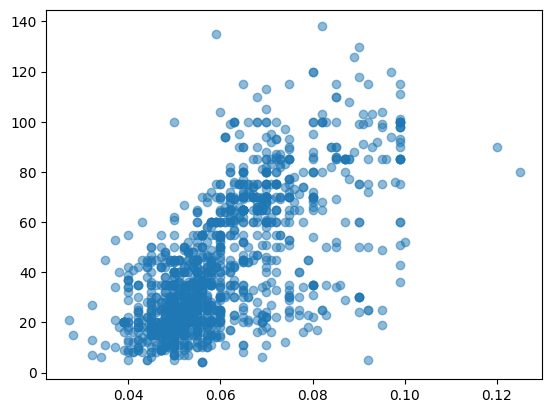

In [152]:
# La manera más sencilla de dibujar la relación lineal entre dos variables numéricas es mediante un scatterplot
plt.scatter(beers['abv'], beers['ibu'], alpha=0.5)
'''
En el scatter plot entre el contenido alcohólico y el amargor, se puede ver esa tendencia ascendente de la que hablamos anteriormente, confirmando esta correlación positiva y moderada.
'''

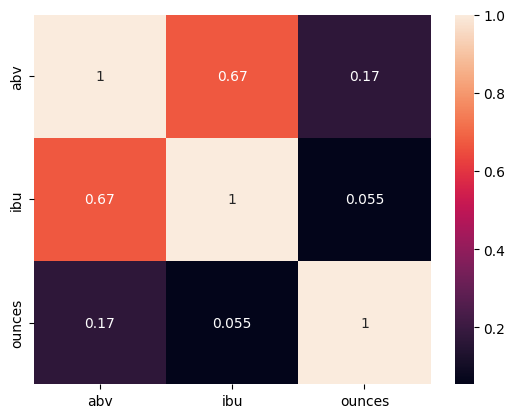

In [153]:
'''
También puede ser interesante hacer un heatmap y se hace con la siguiente sintaxis, en este caso representamos las tres variables numéricas, 
no como en el scatter plot anterior que sólo se representan dos variables, y he elegido las dos variables con correlación positiva
'''
import seaborn as sns
sns.heatmap(beers[['abv','ibu','ounces']].corr(), annot=True)
plt.show()
# Mismos resultados que los comentados anteriormente...

## Ejercicio 13
Representa el nivel de alcohol (columna `abv`) en un histograma. ¿Se trata de una distribución simétrica o asimétrica?

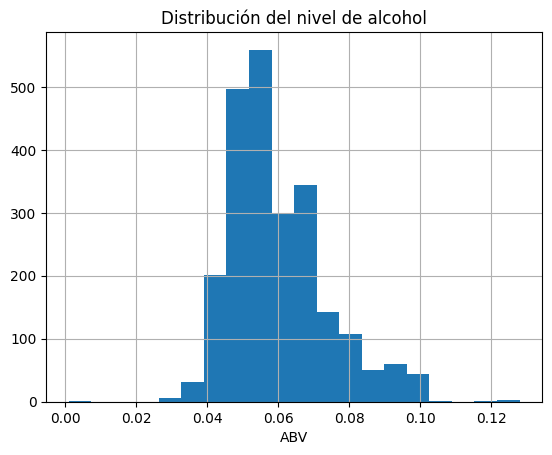

In [154]:
beers['abv'].hist(bins=20)
plt.xlabel('ABV')
plt.title('Distribución del nivel de alcohol')
plt.show()

# No es una distribución simétrica del todo, es ligeramente asimétrica hacía la derecha, por lo que las cervezas tienen un nivel de alcohol moderado, lo cual concuerda con lo que sabemos de este tipo de bebidas.

## Ejercicio 14
Representa mediante un *boxplot* de `seaborn` la variable `abv`

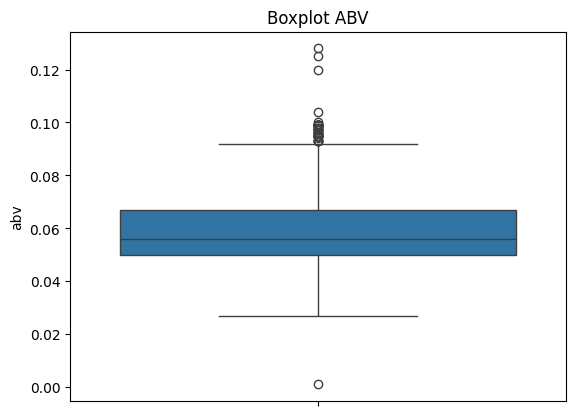

'\nCon el boxplot se hace un gráfico muy útil que representa la mediana y sus cuartiles, así como el máximo y el mínimo\nTambién se representan los outliers, que viene representados por puntos que sobresalen los bigotes.\nEn este boxplot se ve que el contenido alcohólico de la cerveza tiene una mediana de menos de 0.06, por lo que se puede decir\nque la mitad de las cervezas tienen un contenido alcohólico < 0.06. Sin embargo, hay cervezas que tienen un rango alcohólico muy alto,\nque vendría representados por los outliers del máximo. \nEsto confirma que la distrinución no es simétrica, y que es ligeramente asimétrica como se ha comentado en el apartado anterior.\n\n'

In [155]:
# La librería seaborn se ha importado anteriormente, por lo que no hace falta importarla de nuevo
sns.boxplot(y=beers['abv'])
plt.title('Boxplot ABV')
plt.show()
'''
Con el boxplot se hace un gráfico muy útil que representa la mediana y sus cuartiles, así como el máximo y el mínimo
También se representan los outliers, que viene representados por puntos que sobresalen los bigotes.
En este boxplot se ve que el contenido alcohólico de la cerveza tiene una mediana de menos de 0.06, por lo que se puede decir
que la mitad de las cervezas tienen un contenido alcohólico < 0.06. Sin embargo, hay cervezas que tienen un rango alcohólico muy alto,
que vendría representados por los outliers del máximo. 
Esto confirma que la distrinución no es simétrica, y que es ligeramente asimétrica como se ha comentado en el apartado anterior.

'''

## Ejercicio 15
1. ¿Qué estilos son los que tienen en media más alcohol?
2. ¿Y los estilos que son en media más amargos?

In [156]:
# 1. Estilos con más alcohol en media:
'''
Para ver qué estilos tiene más alcohol de media se hace un groupby el estilo y luego la media del contenido alcohólico, ordenando de mayor a menor
y enseñamos los 10 primeros valores
'''
beers.groupby('style')['abv'].mean().sort_values(ascending=False).head(10)

#Los estilos de cerveza que tienen mayor contenido alcohólico son: English Barleywine (media = 0.108), seguido muy de cerca de Quadrupel (media = 0.104)
#y en tercer lugar American Barleywine y American Malt Liquor ambas con un amedia de 0.099.

style
English Barleywine                  0.107667
Quadrupel (Quad)                    0.104000
American Barleywine                 0.099000
American Malt Liquor                0.099000
Russian Imperial Stout              0.097636
American Double / Imperial Stout    0.093667
American Double / Imperial IPA      0.087369
Tripel                              0.086818
Baltic Porter                       0.085167
Belgian Strong Pale Ale             0.084000
Name: abv, dtype: float64

In [157]:
# 2. Estilos más amargos en media
'''
Para ver qué estilos son más amargos de media se hace un groupby el estilo y luego la media del amargor, ordenando de mayor a menor
y enseñamos los 10 primeros valores
'''
beers.groupby('style')['ibu'].mean().sort_values(ascending=False).head(10)



#Los estilos de cerveza más amargos son: American Barleywine (media = 96.0), sefuido de American Double/Imperial IPA (media = 93.32),
#y en tercer lugar Russian Imperial Stout (media = 86.50)


style
American Barleywine                   96.000000
American Double / Imperial IPA        93.320000
Russian Imperial Stout                86.500000
American Double / Imperial Pilsner    85.000000
Belgian Strong Dark Ale               72.000000
American Black Ale                    68.900000
American IPA                          67.634551
English Barleywine                    66.666667
English Stout                         66.000000
American Strong Ale                   65.416667
Name: ibu, dtype: float64

## Ejercicio 16
Carga el datasets de cervecerias `datasets_breweries.csv`

In [158]:
# Importar dataset cervecerias y mirar que se ha importado correctamente con .head
breweries = pd.read_csv('data/datasets_breweries.csv')
breweries.head(10)

,Unnamed: 0,name,city,state
0,0,NorthGate Brewing,Minneapolis,MN
1,1,Against the Grain Brewery,Louisville,KY
2,2,Jack's Abby Craft Lagers,Framingham,MA
3,3,Mike Hess Brewing Company,San Diego,CA
4,4,Fort Point Beer Company,San Francisco,CA
5,5,COAST Brewing Company,Charleston,SC
6,6,Great Divide Brewing Company,Denver,CO
7,7,Tapistry Brewing,Bridgman,MI
8,8,Big Lake Brewing,Holland,MI
9,9,The Mitten Brewing Company,Grand Rapids,MI


## Ejercicio 17
1. Renombra la columna `Unnamed: 0` como `brewery_id`
2. Renombra también la columna `name` por `brewery_name`. ¿Puedes hacer ambos apartados en una sola sentencia?

In [159]:
# 1. Renombra la columna `Unnamed: 0` como `brewery_id`
breweries.rename(columns={'Unnamed: 0': 'brewery_id'}, inplace=True)
breweries

,brewery_id,name,city,state
0,0,NorthGate Brewing,Minneapolis,MN
1,1,Against the Grain Brewery,Louisville,KY
2,2,Jack's Abby Craft Lagers,Framingham,MA
3,3,Mike Hess Brewing Company,San Diego,CA
4,4,Fort Point Beer Company,San Francisco,CA
...,...,...,...,...
553,553,Covington Brewhouse,Covington,LA
554,554,Dave's Brewfarm,Wilson,WI
555,555,Ukiah Brewing Company,Ukiah,CA
556,556,Butternuts Beer and Ale,Garrattsville,NY


In [160]:
#2. Renombra también la columna `name` por `brewery_name`.
breweries.rename(columns={'name': 'brewery_name'}, inplace=True)
breweries

,brewery_id,brewery_name,city,state
0,0,NorthGate Brewing,Minneapolis,MN
1,1,Against the Grain Brewery,Louisville,KY
2,2,Jack's Abby Craft Lagers,Framingham,MA
3,3,Mike Hess Brewing Company,San Diego,CA
4,4,Fort Point Beer Company,San Francisco,CA
...,...,...,...,...
553,553,Covington Brewhouse,Covington,LA
554,554,Dave's Brewfarm,Wilson,WI
555,555,Ukiah Brewing Company,Ukiah,CA
556,556,Butternuts Beer and Ale,Garrattsville,NY


In [ ]:
# 2b. ¿Puedes hacer ambos apartados en una sola sentencia? Si, con un diccionario y el rename:
breweries.rename(columns={'Unnamed: 0': 'brewery_id','name': 'brewery_name'}, inplace=True)
breweries

,brewery_id,brewery_name,city,state
0,0,NorthGate Brewing,Minneapolis,MN
1,1,Against the Grain Brewery,Louisville,KY
2,2,Jack's Abby Craft Lagers,Framingham,MA
3,3,Mike Hess Brewing Company,San Diego,CA
4,4,Fort Point Beer Company,San Francisco,CA
...,...,...,...,...
553,553,Covington Brewhouse,Covington,LA
554,554,Dave's Brewfarm,Wilson,WI
555,555,Ukiah Brewing Company,Ukiah,CA
556,556,Butternuts Beer and Ale,Garrattsville,NY


## Ejercicio 18
Junta los dos datasets que tienes

In [163]:
beer_breweries = pd.merge(beers, breweries, on='brewery_id')
# Usamos la columna brewery_id que es la que tienen en común los dos datasets
beer_breweries.head(10)

,abv,ibu,id,name,style,brewery_id,ounces,brewery_name,city,state
0,0.050,NaN,1436,Pub Beer,American Pale Lager,408,12.0,10 Barrel Brewing Company,Bend,OR
1,0.066,NaN,2265,Devil's Cup,American Pale Ale (APA),177,12.0,18th Street Brewery,Gary,IN
2,0.071,NaN,2264,Rise of the Phoenix,American IPA,177,12.0,18th Street Brewery,Gary,IN
3,0.090,NaN,2263,Sinister,American Double / Imperial IPA,177,12.0,18th Street Brewery,Gary,IN
4,0.075,NaN,2262,Sex and Candy,American IPA,177,12.0,18th Street Brewery,Gary,IN
5,0.077,NaN,2261,Black Exodus,Oatmeal Stout,177,12.0,18th Street Brewery,Gary,IN
6,0.045,NaN,2260,Lake Street Express,American Pale Ale (APA),177,12.0,18th Street Brewery,Gary,IN
7,0.065,NaN,2259,Foreman,American Porter,177,12.0,18th Street Brewery,Gary,IN
8,0.055,NaN,2258,Jade,American Pale Ale (APA),177,12.0,18th Street Brewery,Gary,IN
9,0.086,NaN,2131,Cone Crusher,American Double / Imperial IPA,177,12.0,18th Street Brewery,Gary,IN


## Ejercicio 19
1. ¿Cuántos estados diferentes hay?
2. ¿Y ciudades diferentes?
3. ¿Cuántas cervecerías hay?

In [ ]:
# 1. ¿Cuántos estados diferentes hay?
print(f"Estados: {beer_breweries['state'].nunique()}")
# usamos un nunique para ver cuantos estados diferentes hay.
# Hay un total de 51 estados diferentes.

Estados: 51


In [ ]:
# 2. ¿Y ciudades diferentes?
print(f"Ciudades: {beer_breweries['city'].nunique()}")
# Lo mismo que antes pero con ciudades
# Hay un total de 384 ciudades

Ciudades: 384


In [ ]:
# 3. ¿Cuántas cervecerías hay?
print(f"Cervecerías: {beer_breweries['brewery_name'].nunique()}")
# Lo mismo que antes pero con nombres de cervecerías
# Hay un total de 551 cervecerías.

Cervecerías: 551


## Ejercicio 20
Agrupa por estado y ciudad, la media, mediana y máximo nivel de alcohol

In [174]:
beer_breweries.groupby(['state', 'city'])['abv'].agg(['mean', 'median', 'max']).reset_index()
# Para agrupar se usa un groupby de estado y ciudad, y luego elegimos la variable a la que queremos ver los estadísticos
# A continuación se usa un aggregate (en este caso abreviado) con los estadísticos que queremos, en este caso media, mediana y máximo.

,state,city,mean,median,max
0,AK,Anchorage,0.054200,0.0520,0.063
1,AK,Juneau,0.053000,0.0530,0.053
2,AK,Soldotna,0.058500,0.0580,0.068
3,AK,Talkeetna,0.059500,0.0585,0.065
4,AL,Birmingham,0.065400,0.0600,0.093
...,...,...,...,...,...
396,WI,Wilson,0.055000,0.0550,0.055
397,WV,Lewisburg,0.062000,0.0620,0.067
398,WY,Jackson,0.054857,0.0520,0.068
399,WY,Pinedale,0.061000,0.0610,0.072


## Ejercicio 21
¿Cuáles son las cervezas más amargas que se consumen en Indiana, estado = `IN`?

In [ ]:
indiana = beer_breweries[beer_breweries['state'] == ' IN']
indiana.sort_values('ibu', ascending=False)[['name', 'ibu', 'city']].head(10)
# Para ver cuales son las cervezas más amargas que se consumen en Indiana, seleccionamos por medio de la columna estado Indiana.
# A continuación se ordenan de mayor a menor, y sacamos el nombre de la cerveza, el amargor y la ciudad.
# Las cervezas más amargas que se consumen en Indiana son: Hopkick Dropkick, Overlord Imperial ambas con la misma amargura.

,name,ibu,city
479,Hopkick Dropkick,115.0,Michigan City
2191,Overlord Imperial IPA,115.0,Evansville
811,Half Cycle IPA,104.0,Indianapolis
2062,Isis,91.0,Indianapolis
2189,Csar,90.0,Evansville
850,The Gadget,90.0,Valparaiso
483,3:33 Black IPA,86.0,Michigan City
1623,Mound Builder IPA,77.0,Lafayette
2047,Grapefruit Jungle (GFJ),77.0,Indianapolis
2064,Grapefruit Jungle (GFJ) (2011),77.0,Indianapolis


## Ejercicio 22
Obtén una tabla con los principales estadísticos del campo `ibu`,  a nivel ciudad

In [176]:
beer_breweries.groupby('city')['ibu'].describe()
# Para imprimir la tabla con los principales estadísticos se usa .describe(), y luego groupy ciudad y la variable a estudiar amargor (ibu)

,count,mean,std,min,25%,50%,75%,max
city,,,,,,,,
Abingdon,1.0,135.000000,NaN,135.0,135.00,135.0,135.00,135.0
Abita Springs,3.0,27.333333,21.455380,13.0,15.00,17.0,34.50,52.0
Ada,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Afton,4.0,43.000000,19.899749,22.0,28.00,45.0,60.00,60.0
Airway Heights,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
Woodinville,4.0,46.750000,18.643587,27.0,39.75,44.0,51.00,72.0
Worcester,1.0,69.000000,NaN,69.0,69.00,69.0,69.00,69.0
Yakima,2.0,54.000000,22.627417,38.0,46.00,54.0,62.00,70.0


## Ejercicio 23
Consigue en un DataFrame de todas las cervezas en cuyas cervecerías al menos haya una cerveza con un `abv` mínimo 0.07.

In [ ]:
# Paso 1: encontrar cervecerías que tienen al menos una cerveza con abv >= 0.07
breweries_high_abv = beer_breweries.groupby('brewery_name')['abv'].max()
breweries_validas = breweries_high_abv[breweries_high_abv >= 0.07].index

# Paso 2: filtrar todas las cervezas de esas cervecerías
resultado = beer_breweries[beer_breweries['brewery_name'].isin(breweries_validas)]
resultado
# Cansada para explicar esto...

,abv,ibu,id,name,style,brewery_id,ounces,brewery_name,city,state
1,0.066,NaN,2265,Devil's Cup,American Pale Ale (APA),177,12.0,18th Street Brewery,Gary,IN
2,0.071,NaN,2264,Rise of the Phoenix,American IPA,177,12.0,18th Street Brewery,Gary,IN
3,0.090,NaN,2263,Sinister,American Double / Imperial IPA,177,12.0,18th Street Brewery,Gary,IN
4,0.075,NaN,2262,Sex and Candy,American IPA,177,12.0,18th Street Brewery,Gary,IN
5,0.077,NaN,2261,Black Exodus,Oatmeal Stout,177,12.0,18th Street Brewery,Gary,IN
...,...,...,...,...,...,...,...,...,...,...
2405,0.067,45.0,928,Belgorado,Belgian IPA,424,12.0,Wynkoop Brewing Company,Denver,CO
2406,0.052,NaN,807,Rail Yard Ale,American Amber / Red Ale,424,12.0,Wynkoop Brewing Company,Denver,CO
2407,0.055,NaN,620,B3K Black Lager,Schwarzbier,424,12.0,Wynkoop Brewing Company,Denver,CO
2408,0.055,40.0,145,Silverback Pale Ale,American Pale Ale (APA),424,12.0,Wynkoop Brewing Company,Denver,CO


## Ejercicio 24
Teniendo en cuenta la media de amargor de todas las cervezas, obtén una tabla con las cervezas cuyos estados tengan una media de amargor en cerveza por encima de la media

In [ ]:
# Media global de amargor
media_global = beer_breweries['ibu'].mean()
# Media de ibu por estado
media_por_estado = beer_breweries.groupby('state')['ibu'].mean()
# Estados por encima de la media global
estados_amargos = media_por_estado[media_por_estado > media_global]
estados_amargos.sort_values(ascending=False)
# Lo siento Itzasain estoy muy cansada para explicar esto ahora...

state
WV    57.500000
NM    57.000000
DC    55.250000
ID    55.117647
ME    52.857143
DE    52.000000
AL    51.222222
MN    49.956522
NH    48.500000
OR    47.942529
CO    47.431507
FL    46.756757
NV    46.500000
MS    46.454545
NJ    46.375000
GA    46.285714
CA    46.281481
NY    46.000000
UT    45.545455
VA    45.371429
WA    44.976744
OH    44.187500
NC    43.300000
IN    42.989011
Name: ibu, dtype: float64